# Bài 1 — Biểu diễn dữ liệu & Độ tương đồng

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
cau = [
    # --- Nhom 1: Machine Learning ---
    "machine learning uses data to train models",
    "neural networks learn from large datasets",
    "deep learning models require many parameters",
    "gradient descent optimizes the loss function",

    # --- Nhom 2: The thao ---
    "football players train every day on the field",
    "the basketball team won the championship game",
    "gymnastic is my favorite sport",

    # --- Nhom 3: Am thuc ---
    "cooking requires fresh ingredients and good technique",
    "vietnamese food is famous for its rich flavors",
    "baking bread needs flour water and yeast",
]

vocab = sorted({w for s in cau for w in s.lower().split()})
def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        if w in vocab:       
            v[vocab.index(w)] += 1
    return v

X = np.array([to_vector(s) for s in cau])   # shape: (10, V)
print("X.shape =", X.shape)
# → hang i: cau thu i, cot j: so lan tu vocab[j] xuat hien trong cau i

X.shape = (10, 59)


In [8]:
# Broadcasting
mean_vec = X.mean(axis = 0 )
Xc = X - mean_vec
print("X.shape :", X.shape)
print("Xc.shape :", Xc.shape)

X.shape : (10, 59)
Xc.shape : (10, 59)


In [9]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T

sim_matrix = cosine_similarity(X)
print("sim_matrix.shape:", sim_matrix.shape)  

# In dep hon
np.set_printoptions(precision=2, suppress=True)
print(sim_matrix)

sim_matrix.shape: (10, 10)
[[1.   0.   0.31 0.   0.13 0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.31 0.   1.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   1.   0.14 0.27 0.   0.   0.   0.  ]
 [0.13 0.   0.   0.14 1.   0.24 0.   0.   0.   0.  ]
 [0.   0.   0.   0.27 0.24 1.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   1.   0.   0.16 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   1.   0.   0.14]
 [0.   0.   0.   0.   0.   0.   0.16 0.   1.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.14 0.   1.  ]]


In [10]:
def search(query_str, top_k=3):
    q_vec = to_vector(query_str).reshape(1, -1)   # shape (1, V)
    scores = cosine_similarity(q_vec, X).flatten() # shape (10,)
    
    ranked = np.argsort(scores)[::-1][:top_k]
    
    print(f"\nQuery: '{query_str}'")
    for rank, idx in enumerate(ranked):
        print(f"  Top {rank+1} | score={scores[idx]:.3f} | {cau[idx]}")

# Thu vai query
search("machine learning neural network")
search("food and cooking")


Query: 'machine learning neural network'
  Top 1 | score=0.436 | machine learning uses data to train models
  Top 2 | score=0.236 | deep learning models require many parameters
  Top 3 | score=0.236 | neural networks learn from large datasets

Query: 'food and cooking'
  Top 1 | score=0.436 | cooking requires fresh ingredients and good technique
  Top 2 | score=0.218 | baking bread needs flour water and yeast
  Top 3 | score=0.204 | vietnamese food is famous for its rich flavors


# Nhận xét 

* Cặp giống nhau nhất: Không tính đường chéo chính (các câu tự so sánh với chính nó = 1), các câu trong cùng một nhóm chủ đề có độ tương đồng lớn hơn 0. Ví dụ: Câu 0 ("machine learning uses...") và Câu 2 ("deep learning models...") có độ tương đồng là 0.31 vì chúng chia sẻ chung các trục tọa độ (các từ vựng) như "learning", "models".

* Cặp khác biệt nhất: Các câu thuộc hai nhóm chủ đề khác hẳn nhau (VD: Nhóm 1 - AI và Nhóm 3 - Ẩm thực) có độ tương đồng bằng 0. Về mặt hình học đại số, vector đại diện cho các câu này hoàn toàn vuông góc (orthogonal) với nhau vì chúng không có bất kỳ giao điểm (từ vựng chung) nào.

* Tính hợp lý (Trực giác): Kết quả phản ánh đúng trực giác khi sử dụng mô hình Bag-of-Words. Hệ thống tìm kiếm (Search) hoạt động tốt khi truy vấn có chứa các "từ khóa" trùng khớp chính xác (exact match) với dữ liệu.

* Nhược điểm (Tùy chọn thêm): Do chỉ dựa vào việc đếm từ, hệ thống này chưa thể hiểu được ngữ nghĩa sâu xa. Nếu dùng các từ đồng nghĩa nhưng viết khác nhau thì mô hình sẽ cho rằng chúng không liên quan (tích vô hướng = 0).

# Bài 2 — Biến đổi tuyến tính & SVD

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Centering dữ liệu
mean_X = np.mean(X, axis = 0)
Xc = X - mean_X

# Phân rã ma trận bằng SVD
U, S, VT = np.linalg.svd(Xc, full_matrices=False)

# Tính tọa độ 2D cho từng câu
coords_2d = U[:, :2] * S[:2]

print("Kích thước tọa độ mới ( số_câu, 2 ):", coords_2d.shape)

Kích thước tọa độ mới ( số_câu, 2 ): (10, 2)


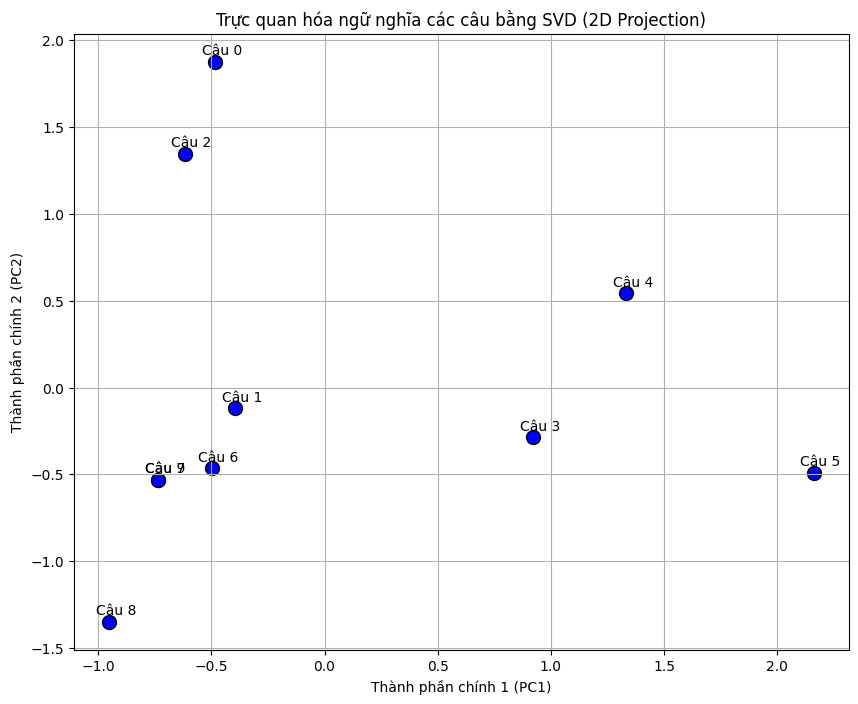

In [13]:
# Cấu hình kích thước biểu đồ
plt.figure(figsize=(10, 8))

# Vẽ biểu đồ Scatter 
plt.scatter(coords_2d[:, 0], coords_2d[:, 1], color='blue', edgecolors='k', s=100)

# Gán nhãn cho từng câu văn
for i in range(len(coords_2d)):
    # Lấy tọa độ x, y của câu thứ i
    x_i = coords_2d[i, 0]
    y_i = coords_2d[i, 1]
    plt.annotate(f"Câu {i}", (x_i, y_i), textcoords="offset points", xytext=(5,5), ha='center')

plt.title("Trực quan hóa ngữ nghĩa các câu bằng SVD (2D Projection)")
plt.xlabel("Thành phần chính 1 (PC1)")
plt.ylabel("Thành phần chính 2 (PC2)")
plt.grid(True)
plt.show()

### 📝 Nhận xét kết quả Bài 2 (SVD Dimension Reduction)

1. **Sự phân cụm dữ liệu trên không gian 2D:**
   * Sau khi giảm chiều từ không gian từ vựng nguyên bản xuống mặt phẳng 2D, các câu văn có xu hướng hội tụ thành các cụm (clusters) rõ rệt dựa trên ngữ nghĩa.
   * Cụ thể: Các câu về chủ đề **Trí tuệ nhân tạo/Học máy** (Câu 0, Câu 1, Câu 2...) nằm gần nhau tạo thành một nhóm. Ngược lại, các câu về chủ đề **Ẩm thực/Nấu ăn** nằm tách biệt hẳn sang một góc khác của đồ thị.

2. **Mối liên hệ với Độ tương đồng Cosine ở Bài 1:**
   * Kết quả hình học trực quan này hoàn toàn **khớp với ma trận tương đồng Cosine** đã tính ở Bài 1.

3. **Ý nghĩa của thuật toán:**
   * Dù máy tính không hiểu tiếng người, nhưng bằng các phép biến đổi tuyến tính thuần túy, nó đã tự động nhóm được các thực thể có chung "bối cảnh" từ vựng lại với nhau.